In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_valid.npy
/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_test.npy
/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_train.npy


In [47]:
import numpy as np
import cuml
import cupy as cp
import matplotlib.pyplot as plt
import cudf
import datasets

In [48]:
ds = datasets.load_dataset("iitolstykh/LLMTrace_classification")
y_train = [0 if label == 'ai' else 1 for label in ds['train']['label']]

In [49]:
X_train = np.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_train.npy')
norm = np.linalg.norm(X_train, axis=1, keepdims=True)
X_train /= norm
X_train.mean(axis=1), X_train.var(axis=1)

(array([-4.780e-05, -4.196e-05, -1.956e-04, ..., -9.960e-05,  2.408e-05,
        -1.633e-04], dtype=float16),
 array([0.001302, 0.001302, 0.001302, ..., 0.001302, 0.001304, 0.001302],
       dtype=float16))

In [50]:
X_train_cupy = cp.array(X_train)

In [51]:
pca = cuml.decomposition.PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cupy)
# print(X_train_pca[:, 0])
# print(X_train_pca[:, 1])

/tmp/ipykernel_55/4225205255.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


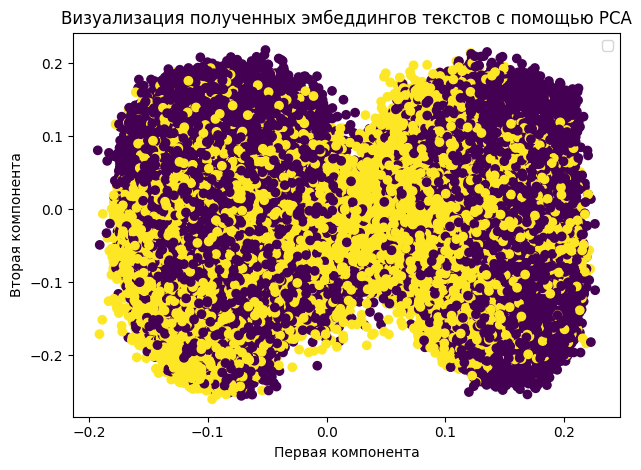

In [52]:
plt.scatter(X_train_pca.get()[:, 0], X_train_pca.get()[:, 1], c=y_train)
plt.xlabel('Первая компонента')
plt.ylabel('Вторая компонента')
plt.title('Визуализация полученных эмбеддингов текстов с помощью PCA')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
from cuml import LogisticRegression

In [54]:
y_train = cp.array(y_train)

lr = LogisticRegression(max_iter=2500)
lr.fit(X_train, y_train)

LogisticRegression()

In [55]:
X_test = cp.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_test.npy')
y_test = cp.array([0 if label == 'ai' else 1 for label in ds['test']['label']])

In [56]:
preds = lr.predict(X_test)

In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test.get(), preds.get()))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87     54484
           1       0.80      0.79      0.80     36466

    accuracy                           0.84     90950
   macro avg       0.83      0.83      0.83     90950
weighted avg       0.84      0.84      0.84     90950



(86696,)
(86696, 2)
Before: 0.6327220299866291


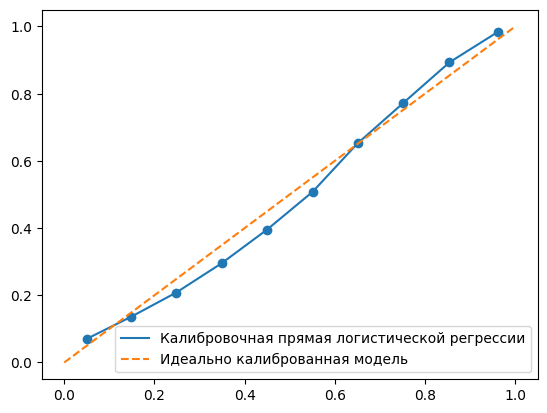

In [76]:
from sklearn.calibration import calibration_curve
X_valid = cp.load('/kaggle/input/datasets/dmytriypan/llmtrace-e5-embeddings/embeddings_valid.npy')
y_valid = cp.array([0 if label == 'ai' else 1 for label in ds['validation']['label']])
print(y_valid.shape)
probs_valid = lr.predict_proba(X_valid)
print(probs_valid.shape)

prob_true, prob_pred = calibration_curve(y_valid.get(), probs_valid.get()[:,0], n_bins=10, pos_label=0, )
plt.plot(prob_pred, prob_true, label='Калибровочная прямая логистической регрессии')
plt.plot([0,1], [0, 1], linestyle='--', label='Идеально калиброванная модель ')

plt.scatter(prob_pred, prob_true)
plt.legend()

In [59]:
# val_pred = lr.predict(X_valid)
# print(classification_report(y_valid.get(), val_pred.get()))

In [75]:
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression()
# print(cp.asnumpy(probs_valid[:, 0]).reshape(-1, 1).shape)
probs_valid_np = probs_valid[:, 0].reshape(-1, 1).get()
y_valid_np = y_valid.get()
calibrator.fit(probs_valid_np, y_valid_np)
calib_probs_valid = calibrator.predict_proba(probs_valid_np)[:, 0]

In [61]:
np.unique(y_valid_np)

array([0, 1])

In [62]:
print(calib_probs_valid)

[0.05833936 0.95764385 0.95406392 ... 0.22100357 0.15374052 0.95377807]


In [63]:
# Подбор порога классификации

from sklearn.metrics import f1_score

best_f1 = 0
best_thr = 0
for thr in np.linspace(0.1, 0.9, 100):
    preds_labels = (calib_probs_valid > thr).astype(np.int32)
    preds_labels = 1 - preds_labels
    # print(preds_labels)
    f1 = f1_score(y_valid_np, preds_labels, pos_label=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f'''
лучший показатель f1 меры {best_f1} при пороге классификации {best_thr}
''')


лучший показатель f1 меры 0.8662303168279264 при пороге классификации 0.4878787878787879



In [64]:
probs_test = lr.predict_proba(X_test)[:, 0].reshape(-1, 1).get()
calib_probs_test = calibrator.predict_proba(probs_test)[:, 0]
# print(probs_test,'\n======\n' ,calib_probs_test)
pred_test_labels = (calib_probs_test < best_thr).astype(np.int32)
print(classification_report(y_true=y_test.get(), y_pred=pred_test_labels))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87     54484
           1       0.81      0.78      0.79     36466

    accuracy                           0.84     90950
   macro avg       0.83      0.83      0.83     90950
weighted avg       0.84      0.84      0.84     90950



In [78]:
from sklearn.metrics import brier_score_loss, log_loss

print("Before:", brier_score_loss(y_valid.get(), probs_valid[:, 0].get()))
print("After :", brier_score_loss(y_valid.get(), calib_probs_valid))

Before: 0.6327220299866291
After : 0.6588277357182504


Калибратор оказался не очень-то и полезным. Что ожидаемо: probs логреги на валидации были уже достаточно неплохими и были близкими к диагональной прямой